# Problem Set 7 for MSDM 5003

Author: LAN, Tianwei 藍天蔚<br>
ID: 21230969<br>
Email: tlanaa@connect.ust.hk

# 1. Autocorrelation of the Absolute Return of S&P500

In [12]:
import yfinance as yf
import pandas as pd

ticker = "^GSPC"
start_date = "1927-12-20"
end_date   = "2025-11-01"

# a. no need to read, directly download
df = yf.download(ticker, start=start_date, end=end_date,
                 auto_adjust=False)
# print(df.head(5))

# print(f"length before cleaning: {len(df)}")
df = df.dropna()                 # b. clean the data
df.reset_index(inplace=True)
# print(f"length after cleaning : {len(df)}")

out_file = f"{ticker.replace('^','')}_{start_date}_{end_date}.csv"
df.to_csv(out_file, index=False)


[*********************100%***********************]  1 of 1 completed


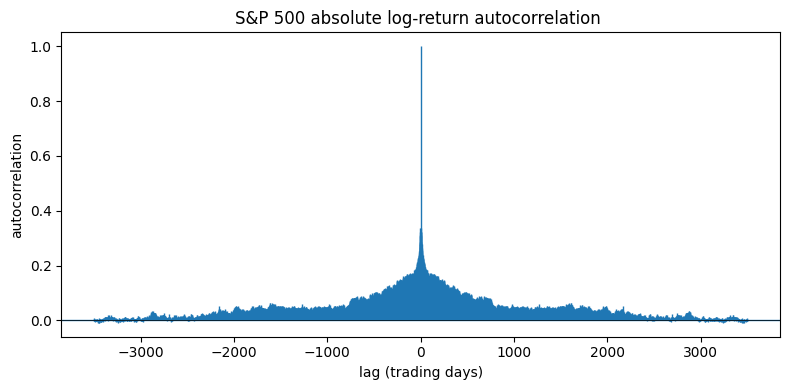

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file = 'GSPC_1927-12-20_2025-11-01.csv'
df   = pd.read_csv(file,
                   parse_dates=['Date'],
                   skiprows=[1], #  <- skip the ticker row
                   dtype={'Adj Close': float})

price = df['Adj Close'].dropna()           
logret = np.log(price / price.shift(1))
absret = np.abs(logret).dropna()            # c. extract absolute returns
absret_z = absret - absret.mean()           # d. subtract by average

# e. Plot auto-correlation, lag ~ 10 years (about 2520 trading days)
max_lag = 3500
plt.figure(figsize=(8,4))
plt.acorr(absret_z, maxlags=max_lag, normed=True, lw=1)
plt.axhline(0, color='k', lw=.5)
plt.title('S&P 500 absolute log-return autocorrelation ')
plt.xlabel('lag (trading days)')
plt.ylabel('autocorrelation')
plt.tight_layout()
plt.show()

When the time lag is 10 years (2520 trading days), the autocorrelation value is close to 0. Any longer lag makes it becomes negative.

Thus suggest a large lag of 2520 trading days.

# 2. PSD of S&P 500

Low-f  beta = 0.770  (f ≤ 0.0040)
High-f beta = 0.022  (f ≥ 0.048)


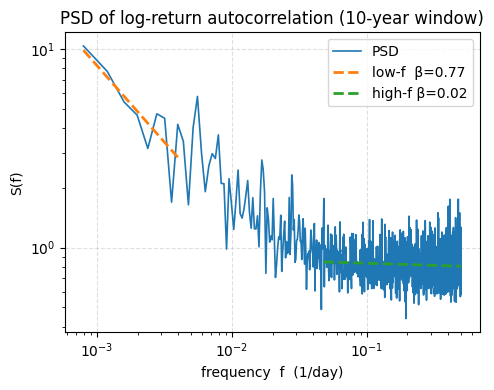

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from sklearn.linear_model import LinearRegression

# Prepare the non-negative branch of the ACF
max_lag = 2520                                       # 10-year horizon
rho = np.correlate(absret_z, absret_z, mode='full')  # bilateral ACF
rho = rho[len(absret_z)-1:]                          # keep lags ≥ 0
rho /= rho[0]                                        # normalise to 1 at lag-0
acf_pos = rho[:max_lag+1]                            # lags 0 … max_lag

# Compute PSD
# FFT of the autocorrelation → spectrum
S_f  = np.real(fft(acf_pos))      # keep real part (imaginary ≈ 0)
freq = fftfreq(len(acf_pos))      # frequency bins [-0.5, 0.5]

# Keep positive frequencies only
mask = freq > 0
f    = freq[mask]
S    = S_f[mask]

# Remove DC (zero-frequency) component to avoid log(0)
f, S = f[1:], S[1:]

# Log–log plot
plt.figure(figsize=(5, 4))
plt.loglog(f, S, lw=1.2, label='PSD')
plt.xlabel('frequency  f  (1/day)')
plt.ylabel('S(f)')
plt.title('PSD of log-return autocorrelation (10-year window)')
plt.grid(True, ls='--', alpha=0.4)

# Define frequency boundaries for low / high regimes
# Low-f:  periods ≥ 1 year          (f ≤ 1/252)
# High-f: periods ≤ ~1 week         (f ≥ 1/21)
f_low_max  = 1/252
f_high_min = 1/21

low_mask  = (f <= f_low_max)
high_mask = (f >= f_high_min)

# Estimate exponent β in S(f) ∝ f^(-β)
def fit_beta(x, y):
    reg = LinearRegression().fit(np.log(x).reshape(-1, 1), np.log(y))
    beta = -reg.coef_[0]
    logA = reg.intercept_
    return beta, logA

# Low-frequency regime
if low_mask.sum() >= 3:          # need ≥ 3 points for regression
    beta_low, logA_low = fit_beta(f[low_mask], S[low_mask])
    print(f'Low-f  beta = {beta_low:.3f}  (f ≤ {f_low_max:.4f})')
    # Overlay fit line
    S_fit_low = np.exp(logA_low) * f[low_mask]**(-beta_low)
    plt.loglog(f[low_mask], S_fit_low, '--', lw=2,
               label=f'low-f  β={beta_low:.2f}')
else:
    print('Too few low-frequency points – β skipped.')

# High-frequency regime
if high_mask.sum() >= 3:
    beta_high, logA_high = fit_beta(f[high_mask], S[high_mask])
    print(f'High-f beta = {beta_high:.3f}  (f ≥ {f_high_min:.3f})')
    S_fit_high = np.exp(logA_high) * f[high_mask]**(-beta_high)
    plt.loglog(f[high_mask], S_fit_high, '--', lw=2,
               label=f'high-f β={beta_high:.2f}')
else:
    print('Too few high-frequency points – β skipped.')

plt.legend()
plt.tight_layout()
plt.show()

Low-frequency: β = 0.77 → long memory.  

High-frequency: β = 0.02 → white noise.

## 3. DFA of S&P500

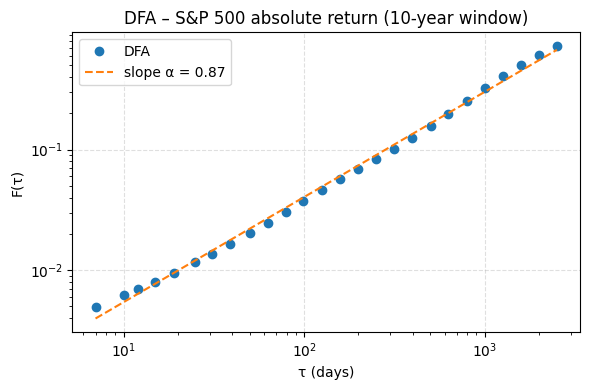

DFA exponent α = 0.873
2α - 1 =  0.746
β =  0.77


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# a.read data and construct cumulative sum
file = 'GSPC_1927-12-20_2025-11-01.csv'
df   = pd.read_csv(file, parse_dates=['Date'], skiprows=[1])
df   = df.sort_values('Date')
price = pd.to_numeric(df['Adj Close'], errors='coerce').dropna()
logret = np.log(price / price.shift(1)).dropna()
absret = np.abs(logret).to_numpy()
Y = np.cumsum(absret - absret.mean())        # cumulative sum (random-walk profile)
# plt.plot(Y)

# b.sliding window method
Ttot = Y.size                                # total length
Tmax = 2520                                  # 10-year max lag (Q1 suggestion)

# build exponential τ sequence
x_min = 0.1 * int(10 * np.log10(7))
x_max = 0.1 * int(10 * np.log10(Tmax))
x_vals = np.arange(x_min, x_max + 0.05, 0.1)
tau_seq = np.unique([int(10**x) for x in x_vals])
tau_seq = tau_seq[(tau_seq >= 7) & (tau_seq <= Tmax)]
# print(tau_seq)

def window_fluctuations(y, tau):
    """
    Compute RMS fluctuation F(tau) using analytical linear-detrend formula.
    Returns *average* F over all windows.
    """
    N  = len(y)
    F2_list = []
    
    x   = np.arange(tau, dtype=float)
    x2  = np.dot(x, x) / tau          # <x²>
    xm  = x.mean()                    # <x>
    denom = x2 - xm**2                # <x²> - <x>²

    for t0 in range(N - tau + 1):
        yy = y[t0:t0+tau]
        y2 = np.dot(yy, yy) / tau     # <y²>
        ym = yy.mean()                # <y>
        xy = np.dot(x, yy) / tau      # <xy>

        slope = (xy - xm * ym) / denom
        F2 = y2 - ym**2 - slope**2 * denom   # F²
        if F2 > 0:
            F2_list.append(F2)

    return np.sqrt(np.mean(F2_list))

F_tau = np.array([window_fluctuations(Y, tau) for tau in tau_seq])

logtau = np.log10(tau_seq)
logF   = np.log10(F_tau)
alpha = np.polyfit(logtau, logF, 1)[0]   # slope = α
logF_pred = alpha * logtau + np.polyfit(logtau, logF, 1)[1] # e. predict F(tau) by regression

plt.figure(figsize=(6,4))
plt.loglog(tau_seq, F_tau, 'o', label='DFA')
plt.loglog(tau_seq, 10**logF_pred, '--',
           label=f'slope α = {alpha:.2f}')
plt.xlabel('τ (days)')
plt.ylabel('F(τ)')
plt.title('DFA – S&P 500 absolute return (10-year window)')
plt.legend()
plt.grid(True, ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

print('DFA exponent α =', round(alpha, 3))
print('2α - 1 = ', round(2*alpha - 1,3))
print('β = ', round(beta_low,3))



So we can see the relation $2\alpha - 1 = \beta$ is valid.